In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
test_df = pd.read_csv('/content/drive/My Drive/Data/Capstone/test.csv')
train_df = pd.read_csv('/content/drive/My Drive/Data/Capstone/train.csv')
BTS_df = pd.read_csv('/content/drive/My Drive/Data/Capstone/BTS_Data.csv')

In [4]:
test_df.info()
train_df.info()
BTS_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Date                  275 non-null    object
 1   Region                275 non-null    object
 2   Brand                 275 non-null    object
 3   Model                 275 non-null    object
 4   Vehicle_Type          275 non-null    object
 5   Battery_Capacity_kWh  275 non-null    int64 
 6   Discount_Percentage   275 non-null    int64 
 7   Customer_Segment      275 non-null    object
 8   Fast_Charging_Option  275 non-null    object
dtypes: int64(2), object(7)
memory usage: 19.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 531 entries, 0 to 530
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Date                  531 non-null    object
 1   Region                531 non-null 

In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [8]:
# USING TRAIN
# clean
df = train_df.dropna()

# numeric columns only
df = df.select_dtypes(include=['number'])

In [9]:
X = df.drop(columns=[df.columns[-1]])  # all except last column
y = df[df.columns[-1]]  # last column as target

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# model 1: linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression MAE:", mae_lr)
print("Linear Regression R2:", r2_lr)

Linear Regression MAE: 757481.258223868
Linear Regression R2: 0.8392342375774808


In [12]:
# model 2: random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest R2:", r2_rf)

Random Forest MAE: 630960.4760996884
Random Forest R2: 0.8280140110091561


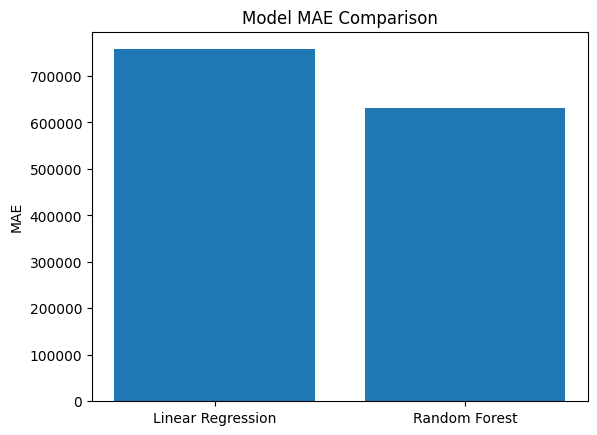

In [14]:
# visual
import matplotlib.pyplot as plt

models = ['Linear Regression', 'Random Forest']
mae_scores = [mae_lr, mae_rf]

plt.bar(models, mae_scores)
plt.title("Model MAE Comparison")
plt.ylabel("MAE")
plt.show()

In [13]:
# comparing models
print("\nModel Comparison:")
print("Linear Regression - MAE:", mae_lr, "R2:", r2_lr)
print("Random Forest - MAE:", mae_rf, "R2:", r2_rf)


Model Comparison:
Linear Regression - MAE: 757481.258223868 R2: 0.8392342375774808
Random Forest - MAE: 630960.4760996884 R2: 0.8280140110091561


demand features

In [43]:
import pandas as pd

train_df = train_df.dropna()

# change date
train_df['Date'] = pd.to_datetime(train_df['Date'])

# time features
train_df['year'] = train_df['Date'].dt.year
train_df['month'] = train_df['Date'].dt.month

In [44]:
# numeric codes
train_df['Brand_Code'] = train_df['Brand'].astype('category').cat.codes

# legend
brand_legend = dict(enumerate(train_df['Brand'].astype('category').cat.categories))

print("Brand Legend:")
for k, v in brand_legend.items():
    print(f"{k}: {v}")

Brand Legend:
0: BMW
1: BYD
2: Ford
3: Hyundai
4: Kia
5: Nissan
6: Tesla
7: Toyota
8: Volkswagen


In [47]:
train_df.columns

Index(['Date', 'Brand', 'Model', 'Vehicle_Type', 'Battery_Capacity_kWh',
       'Discount_Percentage', 'Customer_Segment', 'Fast_Charging_Option',
       'Units_Sold', 'Revenue', 'total_demand', 'year', 'month',
       'revenue_per_unit', 'demand_growth', 'lag_sales', 'Region_Asia',
       'Region_Europe', 'Region_North America', 'Region_Oceania',
       'Region_South America', 'Brand_Code'],
      dtype='object')

In [48]:
X = train_df.drop(columns=[
    'Units_Sold',   # target
    'Date',
    'Brand',        # already encoded
    'Model',        # text
    'Vehicle_Type', # all EV anyway
    'Customer_Segment',
    'Fast_Charging_Option'
], errors='ignore')

y = train_df['Units_Sold']

In [49]:
X = X.select_dtypes(include=['number'])

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [51]:
# model 1: linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression MAE:", mae_lr)
print("Linear Regression R2:", r2_lr)

Linear Regression MAE: 5.250463041278944e-10
Linear Regression R2: 1.0


In [52]:
# model 2: random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest R2:", r2_rf)

Random Forest MAE: 6.928490566037737
Random Forest R2: 0.9860282863544836


In [53]:
# model comapre
print("\nModel Comparison:")
print("----------------------")
print("Linear Regression -> MAE:", mae_lr, "| R2:", r2_lr)
print("Random Forest     -> MAE:", mae_rf, "| R2:", r2_rf)


Model Comparison:
----------------------
Linear Regression -> MAE: 5.250463041278944e-10 | R2: 1.0
Random Forest     -> MAE: 6.928490566037737 | R2: 0.9860282863544836


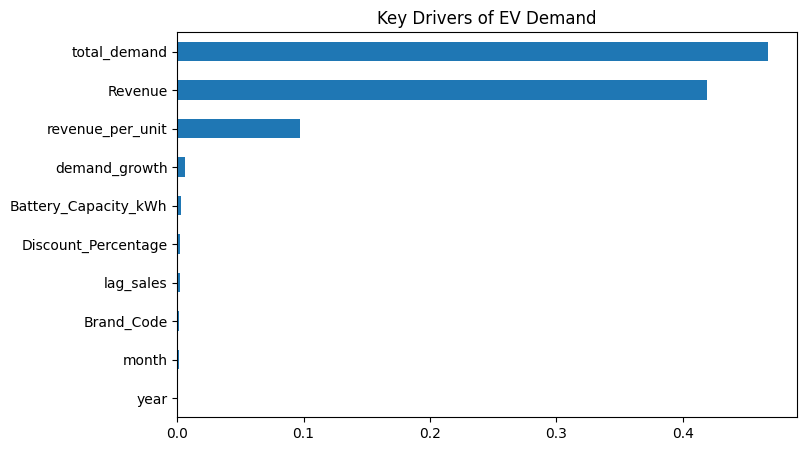

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(rf.feature_importances_, index=X.columns)

importance.sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Key Drivers of EV Demand")
plt.show()

time demand

In [70]:
train_df['Date'] = pd.to_datetime(train_df['Date'], format='%Y-%m')

In [71]:
monthly_demand = train_df.groupby('Date')['Units_Sold'].sum().reset_index()

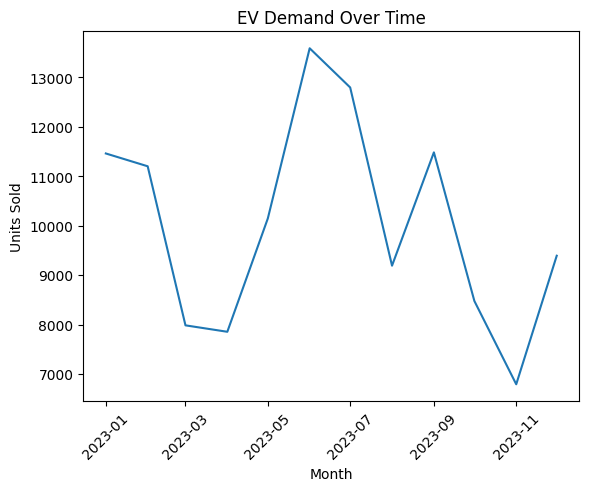

In [72]:
import matplotlib.pyplot as plt

plt.plot(monthly_demand['Date'], monthly_demand['Units_Sold'])
plt.title("EV Demand Over Time")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.show()

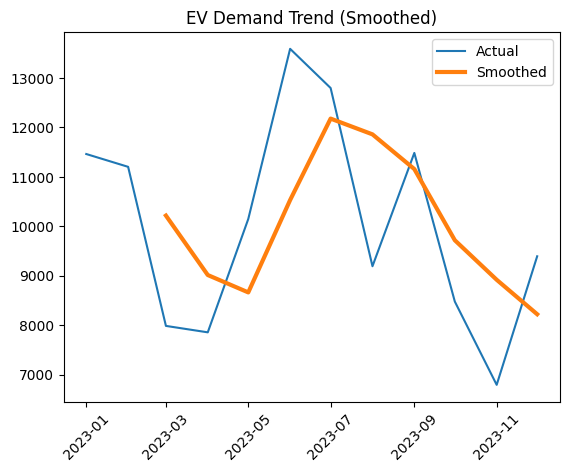

In [73]:
monthly_demand['rolling_avg'] = monthly_demand['Units_Sold'].rolling(3).mean()

plt.plot(monthly_demand['Date'], monthly_demand['Units_Sold'], label='Actual')
plt.plot(monthly_demand['Date'], monthly_demand['rolling_avg'], label='Smoothed', linewidth=3)

plt.title("EV Demand Trend (Smoothed)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

demand by region

In [75]:
region_cols = [col for col in train_df.columns if 'Region_' in col]

In [77]:
region_trend = train_df.groupby('Date')[region_cols].sum().reset_index()

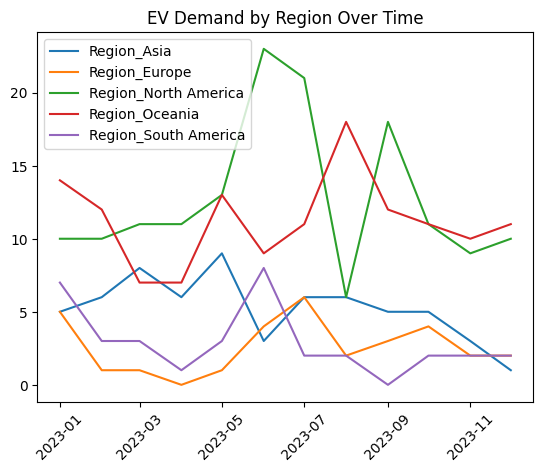

In [78]:
for col in region_cols:
    plt.plot(region_trend['Date'], region_trend[col], label=col)

plt.title("EV Demand by Region Over Time")
plt.legend()
plt.xticks(rotation=45)
plt.show()

BREARU DATA

In [79]:
import pandas as pd
BTS_df = pd.read_csv('/content/drive/My Drive/Data/Capstone/BTS_Data.csv')

In [87]:
import pandas as pd

bts_2023 = pd.DataFrame({
    'vehicle_type': ['Hybrid', 'PHEV', 'EV'],
    'sales': [1175456, 293578, 1164638]
})

In [88]:
bts_2023['type_code'] = bts_2023['vehicle_type'].astype('category').cat.codes

In [89]:
X = bts_2023[['type_code']]
y = bts_2023['sales']

In [90]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

In [91]:
# model 1: linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression MAE:", mae_lr)
print("Linear Regression R2:", r2_lr)

Linear Regression MAE: 446348.0
Linear Regression R2: nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [92]:
# model 2: radnom forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest R2:", r2_rf)

Random Forest MAE: 237293.59999999998
Random Forest R2: nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [93]:
print(bts_2023.sort_values('sales', ascending=False))

  vehicle_type    sales  type_code
0       Hybrid  1175456          1
2           EV  1164638          0
1         PHEV   293578          2


based on this, hybrid in the united states is the type that manufacturers should be focusing on